# Airbnb Amsterdam Data Analysis

## Project Overview

This notebook  explores the Airbnb Amsterdam dataset using Python and Pandas.

The goals of this analysis are to:

1. Assess the quality of the dataset.
2. Clean the data where necessary.
3. Explore relationships between variables.
4. Answer business research questions using data analysis.

### Research Questions

1. Which neighbourhood has the highest Airbnb Listing prices?
2. How does room type affect Airbnb Listing prices?
3. Are there price outliers,and how do they affect the analysis?

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport

%matplotlib inline

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/7r/z88gd3sd0rv_x899l45rkmm40000gn/T/ipykernel_77557/525096276.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


## Laod Dataset

In [2]:
df = pd.read_csv("../data/airbnb.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,27886,"Romantic, stylish B&B houseboat in canal district",97647,Flip,NaN,Centrum-West,52.387610,4.89188,Private room,132.0,3,311,2025-09-07,1.87,1,17,33,0363 974D 4986 7411 88D8
1,28871,Comfortable double room,124245,Edwin,NaN,Centrum-West,52.367750,4.89092,Private room,89.0,2,732,2025-09-07,3.99,2,126,93,0363 607B EA74 0BD8 2F6F
2,29051,Comfortable single / double room,124245,Edwin,NaN,Centrum-Oost,52.365840,4.89111,Private room,61.0,2,849,2025-09-08,4.81,2,95,86,0363 607B EA74 0BD8 2F6F
3,44391,Quiet 2-bedroom Amsterdam city centre apartment,194779,Jan,NaN,Centrum-Oost,52.371680,4.91471,Entire home/apt,NaN,3,42,2022-08-20,0.23,1,0,0,0363 E76E F06A C1DD 172C
4,48373,Cozy family home in Amsterdam South,220434,Vesna & Misha,NaN,Buitenveldert - Zuidas,52.327808,4.87680,Entire home/apt,NaN,3,5,2024-04-28,0.19,1,0,0,0363 4A2B A6AD 0196 F684


## Initial Data Exploration

In [3]:

df.shape

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              10480 non-null  int64  
 1   name                            10480 non-null  object 
 2   host_id                         10480 non-null  int64  
 3   host_name                       10477 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   10480 non-null  object 
 6   latitude                        10480 non-null  float64
 7   longitude                       10480 non-null  float64
 8   room_type                       10480 non-null  object 
 9   price                           5874 non-null   float64
 10  minimum_nights                  10480 non-null  int64  
 11  number_of_reviews               10480 non-null  int64  
 12  last_review                     

id                                    0
name                                  0
host_id                               0
host_name                             3
neighbourhood_group               10480
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                              4606
minimum_nights                        0
number_of_reviews                     0
last_review                        1097
reviews_per_month                  1097
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                             119
dtype: int64

## Data Quality Assessment

In [4]:
profile = ProfileReport (
    df, title = "Airbnb Amsterdam Data Quality Report",
    explorative = True
)

In [5]:
profile.to_file("../reports/airbnb_quality_report.html")

Summarize dataset:  13%|▏| 3/23 [00:00<00:00, 31.91it/s
Summarize dataset:  74%|▋| 17/23 [00:00<00:00, 44.68it/
100%|█████████████████| 18/18 [00:00<00:00, 115.32it/s]
Summarize dataset: 100%|█| 149/149 [00:06<00:00, 23.56i
Generate report structure: 100%|█| 1/1 [00:02<00:00,  2
Render HTML: 100%|███████| 1/1 [00:00<00:00,  2.26it/s]
Export report to file: 100%|█| 1/1 [00:00<00:00, 74.69i


### Overview Observations

The Airbnb Amsterdam dataset contains **10,480 observations and **18 variables**.Data profiling identified **17,402 missing values (9.2%)**,indicating that data cleaning will be necessary before performing further analysis.

No duplicate records were found, which suggests the dataset is free from repeated listings. The dataset occupies approximately **4.9 MiB** of memory and contains a mixture of numeric, categorical, text, and datetime variables suitable for exploratory data analysis.

In [6]:
df[df["price"].isna()].head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
3,44391,Quiet 2-bedroom Amsterdam city centre apartment,194779,Jan,NaN,Centrum-Oost,52.371680,4.914710,Entire home/apt,NaN,3,42,2022-08-20,0.23,1,0,0,0363 E76E F06A C1DD 172C
4,48373,Cozy family home in Amsterdam South,220434,Vesna & Misha,NaN,Buitenveldert - Zuidas,52.327808,4.876800,Entire home/apt,NaN,3,5,2024-04-28,0.19,1,0,0,0363 4A2B A6AD 0196 F684
9,53921,Amsterdam Stylish Lakeview Apartment,252245,Ingrid,NaN,IJburg - Zeeburgereiland,52.355590,5.003200,Entire home/apt,NaN,1,12,2024-05-25,0.14,1,0,0,0363 B43C B1D4 2666 3739
10,55709,Bright Loft in Centre Amsterdam,263233,Jan-Willem,NaN,Centrum-Oost,52.358112,4.897637,Entire home/apt,NaN,11,69,2025-05-13,0.38,1,0,1,0363 E295 7D15 8420 343E
11,55868,Apartment near Museumplein (centre),264178,Cornelie,NaN,Zuid,52.355970,4.885120,Entire home/apt,NaN,3,96,2023-08-07,0.54,1,0,0,0363 B5A3 5F63 B032 A320
12,62015,"Charming, beautifully & sunny place",301340,Jessica,NaN,Oud-Oost,52.364310,4.931220,Entire home/apt,NaN,30,38,2024-03-31,0.21,1,22,0,0363 B090 499C D757 7F4F
13,80635,TOP LOCATED Canalhouse B&B Jordaan,436145,Riks,NaN,Centrum-West,52.378280,4.894400,Private room,NaN,3,241,2022-12-31,1.37,4,0,0,0363 4108 6EC3 C2FF 2493
14,91535,"Privat room and shared Houseboat ""Ramona"" centre",494281,Michiel,NaN,De Pijp - Rivierenbuurt,52.357740,4.896470,Private room,NaN,1,318,2025-09-07,1.85,1,0,71,0363 74BA 2074 E0CF 1CB8
17,155548,Apartment 2 minutes from Centrum!,748161,Maria,NaN,Oud-Oost,52.364200,4.928290,Entire home/apt,NaN,3,21,2019-08-20,0.12,1,0,0,0363 A562 4D7E 4A91 60DF
18,158633,"Typical Dutch house, quiet area, close to centre",761321,Louisa,NaN,Noord-Oost,52.393640,4.945380,Entire home/apt,NaN,3,20,2025-08-30,0.12,1,0,3,0363 D141 1024 C60E 96BA


In [7]:
df_clean = df.dropna(subset=["price"])

In [8]:
df_clean.shape

(5874, 18)

In [9]:
df_clean = df_clean.drop(columns=["neighbourhood_group"]) # neighbourhood column is completely empty.

In [10]:
df_clean.shape

(5874, 17)

## Data Quality Report (Cleaned Dataset)

In [11]:
profile_clean = ProfileReport(
    df_clean,
    title="Cleaned Airbnb Amsterdam Data Quality Report",
    explorative=True
)

In [12]:
profile_clean.to_file("../reports/airbnb_clean_quality_report.html")

Summarize dataset:   9%| | 2/22 [00:00<00:00, 22.98it/s
Summarize dataset:  27%|▎| 6/22 [00:00<00:01, 10.11it/s
Summarize dataset:  77%|▊| 17/22 [00:00<00:00, 29.05it/
100%|██████████████████| 17/17 [00:00<00:00, 34.79it/s]
Summarize dataset: 100%|█| 148/148 [00:06<00:00, 22.95i
Generate report structure: 100%|█| 1/1 [00:02<00:00,  2
Render HTML: 100%|███████| 1/1 [00:00<00:00,  3.43it/s]
Export report to file: 100%|█| 1/1 [00:00<00:00, 84.92i


# Exploratory Data Analysis (EDA)

This section explores the Airbnb Amsterdan dataset to identify trends, patterns, and insights that answer the project's research questions.

The analysis focuses on:
- Price distribution
- Neighbourhood pricing
- Room type pricing
- Price outliers

## Research Question 1

### Which neighbourhood has the highest average Airbnb listing price?

In [13]:
# Average price by neighbourhood

neighbourhood_prices = (
    df_clean
    .groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
)
neighbourhood_prices.head(10)

neighbourhood
Buitenveldert - Zuidas      3013.219512
IJburg - Zeeburgereiland    1730.392523
Oud-Noord                    370.496032
Centrum-West                 315.880519
Zuid                         309.583908
Centrum-Oost                 307.724138
De Pijp - Rivierenbuurt      280.465331
De Baarsjes - Oud-West       271.282258
Watergraafsmeer              268.297101
Westerpark                   255.040816
Name: price, dtype: float64

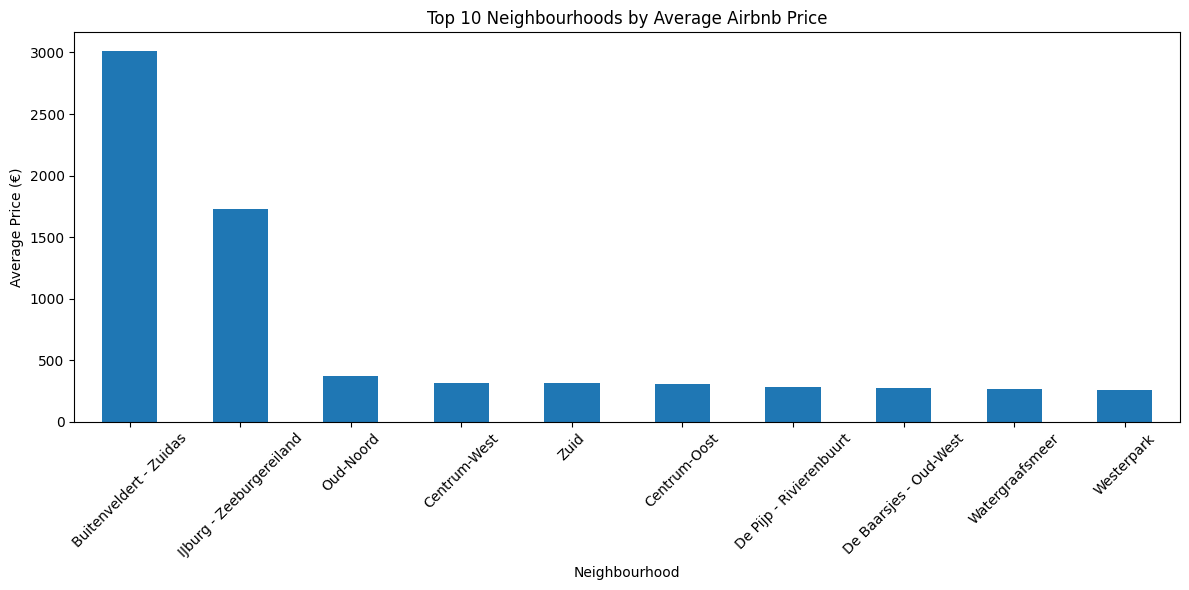

In [14]:
plt.figure(figsize=(12,6))

neighbourhood_prices.head(10).plot(kind="bar")

plt.title("Top 10 Neighbourhoods by Average Airbnb Price")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Price (€)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

The chart shows the ten neighbourhoods with the highest average Airbnb listing prices.

Buitenveldert–Zuidas has the highest average listing price by a large margin, followed by IJburg–Zeeburgereiland. Most other neighbourhoods have considerably lower average prices.

The large difference suggests that a small number of expensive listings may be influencing the average price. This possibility will be investigated further during the outlier analysis.

These findings provide useful insights for property owners, travellers, and businesses interested in Airbnb pricing patterns in Amsterdam.

## Research Question 2:

### How does room type affect Airbnb listing prices?

The objective of this analysis is to compare the average listing price for each Airbnb room type.
Understanding these differences helps identify which types of accommodation generally command the highest prices.

In [15]:
room_type_prices = (
    df_clean
    .groupby("room_type")["price"]
    .mean()
    .sort_values(ascending=False)
)
room_type_prices

room_type
Hotel room         5971.236842
Entire home/apt     336.184245
Private room        175.725275
Shared room         130.266667
Name: price, dtype: float64

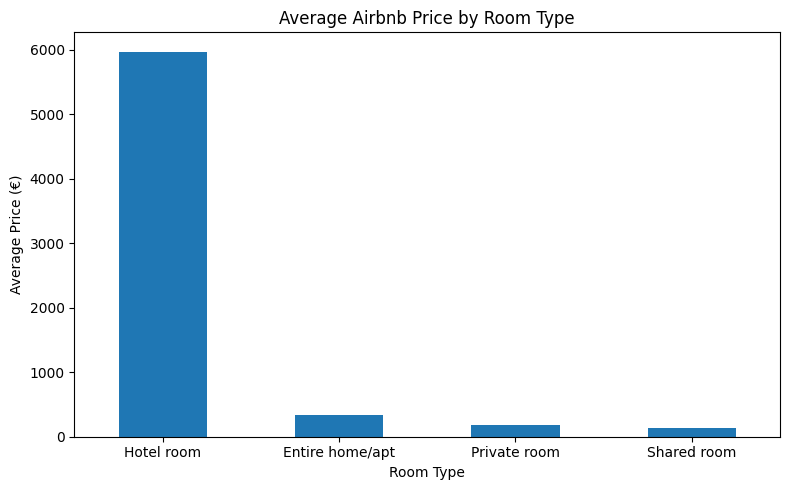

In [16]:
plt.figure(figsize=(8,5))

room_type_prices.plot(kind="bar")

plt.title("Average Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price (€)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretation

The analysis shows clear differences in average listing prices across room types.

Entire homes and apartments generally have the highest average prices because guests have exclusive access to the property and more amenities. Hotel rooms also tend to have relatively high prices depending on location and services provided.

Private rooms are typically more affordable since guests share parts of the property with the host or other occupants. Shared rooms have the lowest average prices, making them the most budget-friendly accommodation option.

These findings can help hosts understand how accommodation type influences pricing and assist travellers in choosing options that match their budget.

### Investigating Hotel Room Prices

The average price for hotel rooms appears much higher than expected. This section investigates whether the result is influenced by extreme outlier listings.

In [17]:
df_clean[df_clean["room_type"] == "Hotel room"]["price"].describe()

count       38.000000
mean      5971.236842
std      15109.445146
min         43.000000
25%        156.250000
50%        231.000000
75%        309.750000
max      50000.000000
Name: price, dtype: float64

In [18]:
df_clean[df_clean["room_type"] == "Hotel room"]\
    .sort_values(by="price",ascending=False)\
    [["name", "price"]]\
    .head(10)

,name,price
6829,Relax in Luxury: Near Town Center and Cycling ...,50000.0
6833,Visit Van Gogh Museum! 3 Units with Full Kitc...,50000.0
6830,City Break in Amsterdam! Large Suite w/ Kitchen,40000.0
8081,Business & Leisure: Stylish Rooms w/ Full Kitchen,40000.0
6832,Convenient Stay! 2 Large 1BR Aprt w/ Full Kitc...,40000.0
6831,Close to Rijksmuseum! Two Units with Full Kitc...,631.0
2948,City Centre Boutique Deluxe Room in Monument,328.0
6826,"Centrally Located! Full Kitchen, Near Vondelpark!",316.0
6828,Elegant Lofts: Perfect Blend of Style & Comfort,316.0
6827,Discover Local Brews: Stay Comfortably in Style,316.0


## Research Question 3

Are there price outliers, and how do they affect the analysis?

The objective of this analysis is to investigate whether the Airbnb dataset contains unusually high or low listing prices.
Price outliers can significantly influence statistical measures such as the mean and may lead to misleading conclusions if not properly examined.

In [19]:
df_clean["price"].describe()

count     5874.000000
mean       336.785155
std       1985.661882
min         35.000000
25%        161.000000
50%        222.000000
75%        314.000000
max      80018.000000
Name: price, dtype: float64

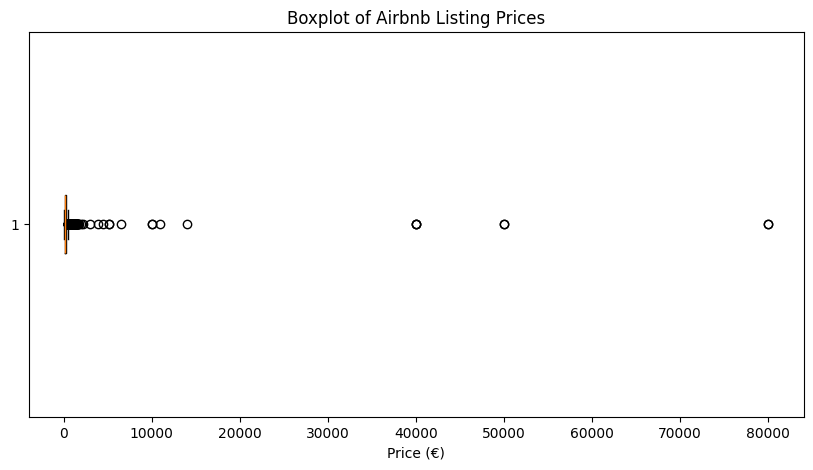

In [20]:
plt.figure(figsize=(10, 5))

plt.boxplot(df_clean["price"],vert=False)

plt.title("Boxplot of Airbnb Listing Prices")
plt.xlabel("Price (€)")

plt.show()

In [21]:
df_clean.sort_values(
    by="price",
    ascending=False
)[["name", "room_type", "neighbourhood", "price"]].head(10)



,name,room_type,neighbourhood,price
7446,Havenlodge+ 4-6 pers Amsterdam,Entire home/apt,IJburg - Zeeburgereiland,80018.0
7447,Havenlodge 4 persoons Amsterdam,Entire home/apt,IJburg - Zeeburgereiland,80018.0
6833,Visit Van Gogh Museum! 3 Units with Full Kitc...,Hotel room,Buitenveldert - Zuidas,50000.0
6829,Relax in Luxury: Near Town Center and Cycling ...,Hotel room,Buitenveldert - Zuidas,50000.0
6830,City Break in Amsterdam! Large Suite w/ Kitchen,Hotel room,Buitenveldert - Zuidas,40000.0
8081,Business & Leisure: Stylish Rooms w/ Full Kitchen,Hotel room,Buitenveldert - Zuidas,40000.0
6832,Convenient Stay! 2 Large 1BR Aprt w/ Full Kitc...,Hotel room,Buitenveldert - Zuidas,40000.0
6374,"Entire Crane, 3 VIP-Suites, Music studio & Jac...",Entire home/apt,Oud-Noord,13978.0
2710,Sweets hotel - Buiksloterdraaibrug,Private room,Oud-Noord,11000.0
412,pay a little more get a lot more,Entire home/apt,Centrum-West,10000.0


### Interpretation

The summary statistics and boxplot indicate that the Airbnb dataset contains several price outliers. Most listings fall within a relatively moderate price range, while a small number of listings have exceptionally high prices.

These extreme values increase the overall average listing price and help explain why the average hotel room price observed in Research Question 2 was much higher than expected.

This analysis highlights the importance of identifying outliers before interpreting summary statistics, as the mean can be strongly influenced by a small number of unusually expensive listings.

# Conclusion

This project analysed Airbnb listings in Amsterdam using Python and the Pandas library to answer three research questions related to listing prices.

The first analysis showed that average Airbnb prices vary considerably across neighbourhoods, indicating that location plays an important role in pricing.

The second analysis demonstrated that room type also influences listing prices. Entire homes and hotel rooms generally have higher average prices than private and shared rooms.

The third analysis investigated price outliers and found that a small number of extremely expensive listings significantly affect the average price. This highlights the importance of identifying outliers before interpreting summary statistics, as they can distort the overall results.

Overall, this project demonstrates how data cleaning, exploratory data analysis, and data visualization can be used to gain meaningful insights from real-world Airbnb data. The techniques used in this notebook can support data-driven decision making in the vacation rental industry.

## Additional Analysis: Mean vs. Median

Because Airbnb prices may include legitimate luxury listings, the mean can be influenced by extreme values. This section compares the mean and median prices to determine which measure better represents the typical Airbnb listing price.

In [22]:
mean_price = df['price'].mean()
median_price = df['price'].median()

print(f"Mean price: €{mean_price:.2f}")
print(f"Median price: €{median_price:.2f}")

Mean price: €336.79
Median price: €222.00


In [23]:
df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)

neighbourhood
Buitenveldert - Zuidas                    3013.219512
IJburg - Zeeburgereiland                  1730.392523
Oud-Noord                                  370.496032
Centrum-West                               315.880519
Zuid                                       309.583908
Centrum-Oost                               307.724138
De Pijp - Rivierenbuurt                    280.465331
De Baarsjes - Oud-West                     271.282258
Watergraafsmeer                            268.297101
Westerpark                                 255.040816
Oud-Oost                                   251.659509
Oostelijk Havengebied - Indische Buurt     216.597403
Bos en Lommer                              204.674330
Noord-West                                 196.994286
Geuzenveld - Slotermeer                    195.846154
Slotervaart                                193.240000
Noord-Oost                                 191.047244
De Aker - Nieuw Sloten                     185.714286
Osdorp        

In [24]:
df.groupby('neighbourhood')['price'].median().sort_values(ascending=False)

neighbourhood
De Pijp - Rivierenbuurt                   250.0
Centrum-West                              245.5
Centrum-Oost                              240.0
De Baarsjes - Oud-West                    240.0
Zuid                                      238.0
Oud-Oost                                  222.0
Westerpark                                214.5
Watergraafsmeer                           213.5
IJburg - Zeeburgereiland                  198.0
Oud-Noord                                 196.5
Oostelijk Havengebied - Indische Buurt    195.0
Slotervaart                               185.5
Bos en Lommer                             184.0
Buitenveldert - Zuidas                    182.5
Geuzenveld - Slotermeer                   182.0
Noord-West                                180.0
Noord-Oost                                169.0
Osdorp                                    153.0
De Aker - Nieuw Sloten                    151.5
Bijlmer-Centrum                           134.0
Gaasperdam - Driemond     

### Interpretation

The mean price is influenced by a small number of very expensive listings. The median provides a better representation of the typical listing price because it is less affected by these extreme values. Since luxury Airbnb properties are valid observations rather than data errors, the median was chosen as the primary measure for comparing neighbourhood prices.

# Conclusion

The comparison between the mean and median demonstrates that Airbnb prices in Amsterdam are influenced by a relatively small number of very expensive listings. Because these luxury properties are valid observations rather than data errors, the median provides a more representative measure of the typical listing price. Therefore, the median was used for neighbourhood price comparisons in this analysis.